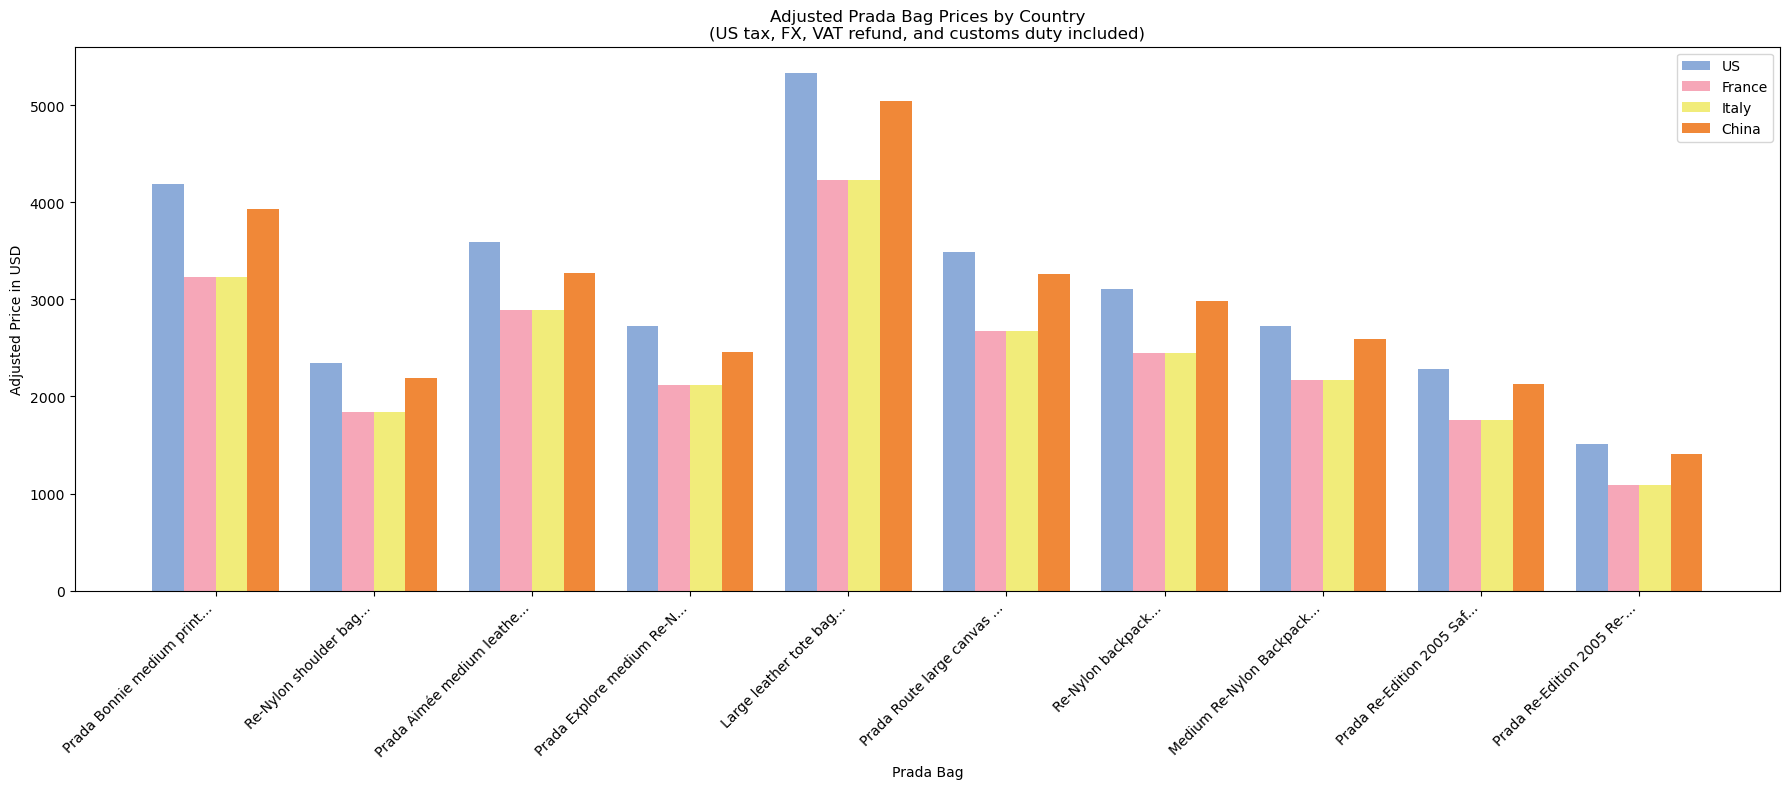

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ----------------------------
# 1. LOAD DATA
# ----------------------------
vat = pd.read_csv("vat_rates_by_country.csv")
tariff = pd.read_csv("tariff_data.csv")
fx = pd.read_csv("Currency_Exchange_Rates.csv")
bags = pd.read_csv("prada_10bags_4countries_cleaned.csv", encoding="latin1")

# ----------------------------
# 2. CLEAN / STANDARDIZE
# ----------------------------
# Standardize country names across files
vat["country"] = vat["Country"].str.strip()
vat = vat[["country", "Approx_Tax_Refund_Rate"]]

fx["country"] = fx["country"].str.strip()
fx = fx[["country", "to_us"]]

tariff["country"] = tariff["country"].str.strip()
tariff = tariff[["country", "Ad Valorem Rate"]]

# Map country codes in bags file
country_map = {
    "US": "US",
    "FR": "France",
    "IT": "Italy",
    "CN": "China"
}
bags["country_full"] = bags["country"].map(country_map)

# ----------------------------
# 3. PIVOT BAG PRICES TO WIDE FORMAT
# ----------------------------
wide = (
    bags.pivot_table(
        index=["key", "product_name"],
        columns="country_full",
        values="price",
        aggfunc="first"
    )
    .reset_index()
)

# ----------------------------
# 4. SET SALES TAX FOR US
# ----------------------------
# Example: NYC = 0.08875
us_sales_tax_rate = 0.08875

# ----------------------------
# 5. BUILD LOOKUP DICTIONARIES
# ----------------------------
refund_lookup = dict(zip(vat["country"], vat["Approx_Tax_Refund_Rate"]))
fx_lookup = dict(zip(fx["country"], fx["to_us"]))
duty_lookup = dict(zip(tariff["country"], tariff["Ad Valorem Rate"]))

# ----------------------------
# 6. CALCULATE ADJUSTED LANDED COSTS
# ----------------------------
# US adjusted price
wide["US_total"] = wide["US"] * (1 + us_sales_tax_rate)

foreign_countries = ["France", "Italy", "China"]

for c in foreign_countries:
    # Convert local price to USD
    wide[f"{c}_converted_usd"] = wide[c] * fx_lookup[c]

    # VAT refund amount in USD
    wide[f"{c}_vat_refund_usd"] = wide[f"{c}_converted_usd"] * refund_lookup[c]

    # Net foreign price after VAT refund
    wide[f"{c}_net_after_refund"] = (
        wide[f"{c}_converted_usd"] - wide[f"{c}_vat_refund_usd"]
    )

    # Customs duty in USD
    # Assumption: duty is applied to the post-refund imported value
    wide[f"{c}_custom_duty_usd"] = (
        wide[f"{c}_net_after_refund"] * duty_lookup[c]
    )

    # Final landed cost
    wide[f"{c}_total"] = (
        wide[f"{c}_net_after_refund"] + wide[f"{c}_custom_duty_usd"]
    )

    # Savings relative to buying in the US
    wide[f"{c}_savings_vs_US"] = wide["US_total"] - wide[f"{c}_total"]

# ----------------------------
# 8. MAKE LABELS FOR X-AXIS
# ----------------------------
# You can use product_name, but they may be long.
# This creates shorter labels using the bag key.
wide["bag_label"] = wide["product_name"].str[:25] + "..."

# If you prefer exact bag codes instead, use:
# wide["bag_label"] = wide["key"]

# ----------------------------
# 9. GROUPED BAR CHART
# ----------------------------
plot_df = wide[["bag_label", "US_total", "France_total", "Italy_total", "China_total"]]

x = np.arange(len(plot_df))
bar_width = 0.2

plt.figure(figsize=(18, 8))

colors = {
    "US": "#8CABD9",
    "France": "#F6A7B8",
    "Italy": "#F1EC7A",
    "China": "#F08838"
}

plt.bar(x - 1.5 * bar_width, plot_df["US_total"], 
        width=bar_width, label="US", color=colors["US"])

plt.bar(x - 0.5 * bar_width, plot_df["France_total"], 
        width=bar_width, label="France", color=colors["France"])

plt.bar(x + 0.5 * bar_width, plot_df["Italy_total"], 
        width=bar_width, label="Italy", color=colors["Italy"])

plt.bar(x + 1.5 * bar_width, plot_df["China_total"], 
        width=bar_width, label="China", color=colors["China"])

plt.xticks(x, plot_df["bag_label"], rotation=45, ha="right")
plt.ylabel("Adjusted Price in USD")
plt.xlabel("Prada Bag")
plt.title("Adjusted Prada Bag Prices by Country\n(US tax, FX, VAT refund, and customs duty included)")
plt.legend()
plt.tight_layout()
plt.savefig("prada_barchart.png")
plt.show()

C:\Users\kayla\AppData\Local\Temp\ipykernel_40056\787435828.py:136: UserWarning: Glyph 128 (\x80) missing from current font.
  plt.tight_layout()
C:\Users\kayla\AppData\Local\Temp\ipykernel_40056\787435828.py:137: UserWarning: Glyph 128 (\x80) missing from current font.
  plt.savefig("ysl_barchart.png")
C:\Users\kayla\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128 (\x80) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


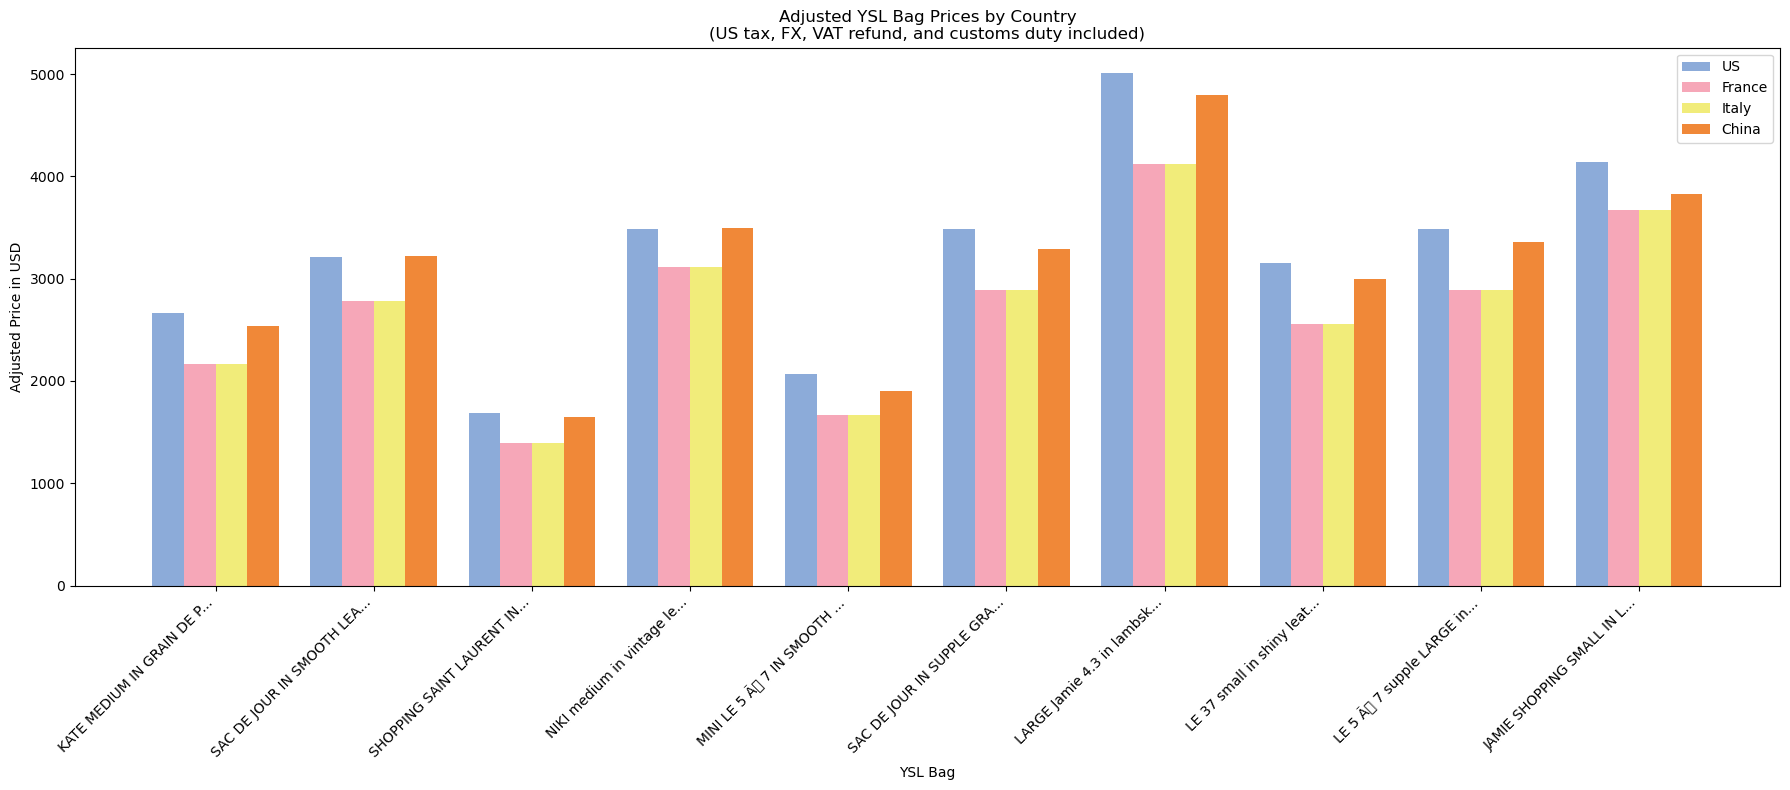

In [29]:
# ----------------------------
# 1. LOAD DATA
# ----------------------------
vat = pd.read_csv("vat_rates_by_country.csv")
tariff = pd.read_csv("tariff_data.csv")
fx = pd.read_csv("Currency_Exchange_Rates.csv")
bags = pd.read_csv("ysl_10bags_4countries_cleaned.csv", encoding="latin1")

# ----------------------------
# 2. CLEAN / STANDARDIZE
# ----------------------------
# Standardize country names across files
vat["country"] = vat["Country"].str.strip()
vat = vat[["country", "Approx_Tax_Refund_Rate"]]

fx["country"] = fx["country"].str.strip()
fx = fx[["country", "to_us"]]

tariff["country"] = tariff["country"].str.strip()
tariff = tariff[["country", "Ad Valorem Rate"]]

# Map country codes in bags file
country_map = {
    "US": "US",
    "FR": "France",
    "IT": "Italy",
    "CN": "China"
}
bags["country_full"] = bags["country"].map(country_map)

# ----------------------------
# 3. PIVOT BAG PRICES TO WIDE FORMAT
# ----------------------------
wide = (
    bags.pivot_table(
        index=["sku", "product_name"],
        columns="country_full",
        values="price",
        aggfunc="first"
    )
    .reset_index()
)

# ----------------------------
# 4. SET SALES TAX FOR US
# ----------------------------
# Example: NYC = 0.08875
us_sales_tax_rate = 0.08875

# ----------------------------
# 5. BUILD LOOKUP DICTIONARIES
# ----------------------------
refund_lookup = dict(zip(vat["country"], vat["Approx_Tax_Refund_Rate"]))
fx_lookup = dict(zip(fx["country"], fx["to_us"]))
duty_lookup = dict(zip(tariff["country"], tariff["Ad Valorem Rate"]))

# ----------------------------
# 6. CALCULATE ADJUSTED LANDED COSTS
# ----------------------------
# US adjusted price
wide["US_total"] = wide["US"] * (1 + us_sales_tax_rate)

foreign_countries = ["France", "Italy", "China"]

for c in foreign_countries:
    # Convert local price to USD
    wide[f"{c}_converted_usd"] = wide[c] * fx_lookup[c]

    # VAT refund amount in USD
    wide[f"{c}_vat_refund_usd"] = wide[f"{c}_converted_usd"] * refund_lookup[c]

    # Net foreign price after VAT refund
    wide[f"{c}_net_after_refund"] = (
        wide[f"{c}_converted_usd"] - wide[f"{c}_vat_refund_usd"]
    )

    # Customs duty in USD
    # Assumption: duty is applied to the post-refund imported value
    wide[f"{c}_custom_duty_usd"] = (
        wide[f"{c}_net_after_refund"] * duty_lookup[c]
    )

    # Final landed cost
    wide[f"{c}_total"] = (
        wide[f"{c}_net_after_refund"] + wide[f"{c}_custom_duty_usd"]
    )

    # Savings relative to buying in the US
    wide[f"{c}_savings_vs_US"] = wide["US_total"] - wide[f"{c}_total"]


# ----------------------------
# 8. MAKE LABELS FOR X-AXIS
# ----------------------------
# You can use product_name, but they may be long.
# This creates shorter labels using the bag key.
wide["bag_label"] = wide["product_name"].str[:25] + "..."

# If you prefer exact bag codes instead, use:
# wide["bag_label"] = wide["key"]

# ----------------------------
# 9. GROUPED BAR CHART
# ----------------------------
plot_df = wide[["bag_label", "US_total", "France_total", "Italy_total", "China_total"]]

x = np.arange(len(plot_df))
bar_width = 0.2

plt.figure(figsize=(18, 8))

colors = {
    "US": "#8CABD9",
    "France": "#F6A7B8",
    "Italy": "#F1EC7A",
    "China": "#F08838"
}

plt.bar(x - 1.5 * bar_width, plot_df["US_total"], 
        width=bar_width, label="US", color=colors["US"])

plt.bar(x - 0.5 * bar_width, plot_df["France_total"], 
        width=bar_width, label="France", color=colors["France"])

plt.bar(x + 0.5 * bar_width, plot_df["Italy_total"], 
        width=bar_width, label="Italy", color=colors["Italy"])

plt.bar(x + 1.5 * bar_width, plot_df["China_total"], 
        width=bar_width, label="China", color=colors["China"])

plt.xticks(x, plot_df["bag_label"], rotation=45, ha="right")
plt.ylabel("Adjusted Price in USD")
plt.xlabel("YSL Bag")
plt.title("Adjusted YSL Bag Prices by Country\n(US tax, FX, VAT refund, and customs duty included)")
plt.legend()
plt.tight_layout()
plt.savefig("ysl_barchart.png")
plt.show()

country_full              key                             product_name  \
0             853971FAF3Y2155              Gucci Giglio large tote bag   
1             863137FAFV29651          Jackie Slim medium shoulder bag   
2             866732AAGIQ1053       Borsetto medium boston leather bag   
3             866732FAFV99653        Borsetto medium boston canvas bag   
4             867360FAF059651             GG Marmont mini shoulder bag   
5             875018AAGIQ1053  Paparazzo medium top handle leather bag   
6             875018FAFV99653   Paparazzo medium top handle canvas bag   
7             875019AAGIQ1053           Paparazzo large top handle bag   
8             A0020YAAGRB1000   Horsebit Ristretto medium shoulder bag   
9             A0022VAAG211096                    Bamboo Tote large bag   

country_full  US_total  France_total  Italy_total  China_total  \
0              2558.56       2115.08      2115.08      2467.08   
1              2340.81       1836.78      1836.78    

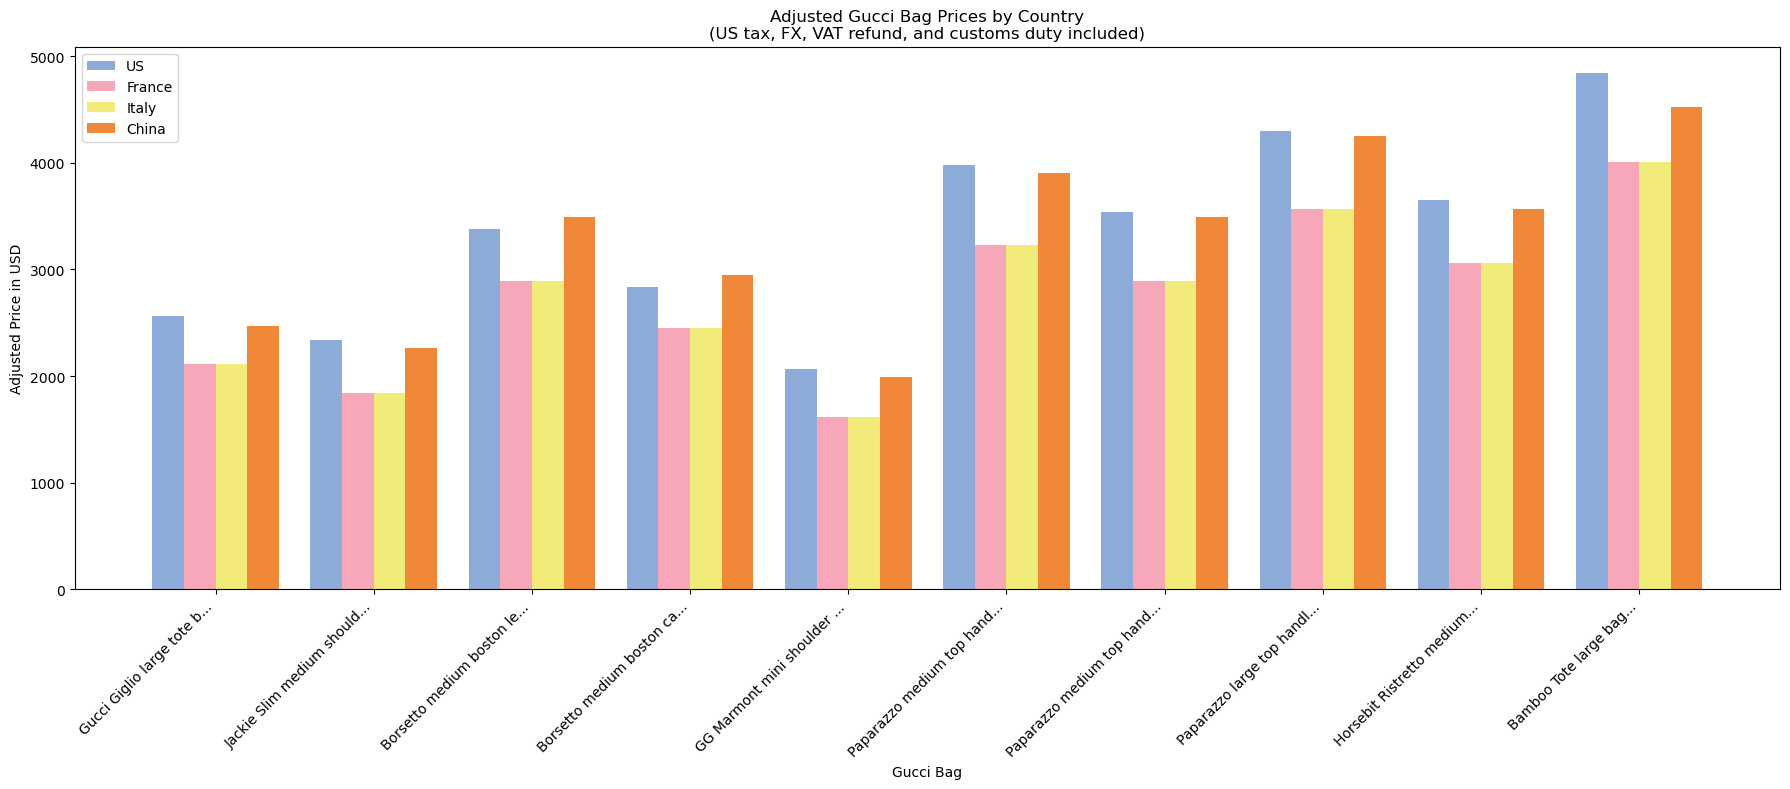

In [5]:
# ----------------------------
# 1. LOAD DATA
# ----------------------------
vat = pd.read_csv("vat_rates_by_country.csv")
tariff = pd.read_csv("tariff_data.csv")
fx = pd.read_csv("Currency_Exchange_Rates.csv")
bags = pd.read_csv("gucci_10bags_4countries_cleaned.csv", encoding="latin1")

# ----------------------------
# 2. CLEAN / STANDARDIZE
# ----------------------------
# Standardize country names across files
vat["country"] = vat["Country"].str.strip()
vat = vat[["country", "Approx_Tax_Refund_Rate"]]

fx["country"] = fx["country"].str.strip()
fx = fx[["country", "to_us"]]

tariff["country"] = tariff["country"].str.strip()
tariff = tariff[["country", "Ad Valorem Rate"]]

# Map country codes in bags file
country_map = {
    "US": "US",
    "FR": "France",
    "IT": "Italy",
    "CN": "China"
}
bags["country_full"] = bags["country"].map(country_map)

# ----------------------------
# 3. PIVOT BAG PRICES TO WIDE FORMAT
# ----------------------------
wide = (
    bags.pivot_table(
        index=["key", "product_name"],
        columns="country_full",
        values="price",
        aggfunc="first"
    )
    .reset_index()
)

# ----------------------------
# 4. SET SALES TAX FOR US
# ----------------------------
# Example: NYC = 0.08875
us_sales_tax_rate = 0.08875

# ----------------------------
# 5. BUILD LOOKUP DICTIONARIES
# ----------------------------
refund_lookup = dict(zip(vat["country"], vat["Approx_Tax_Refund_Rate"]))
fx_lookup = dict(zip(fx["country"], fx["to_us"]))
duty_lookup = dict(zip(tariff["country"], tariff["Ad Valorem Rate"]))

# ----------------------------
# 6. CALCULATE ADJUSTED LANDED COSTS
# ----------------------------
# US adjusted price
wide["US_total"] = wide["US"] * (1 + us_sales_tax_rate)

foreign_countries = ["France", "Italy", "China"]

for c in foreign_countries:
    # Convert local price to USD
    wide[f"{c}_converted_usd"] = wide[c] * fx_lookup[c]

    # VAT refund amount in USD
    wide[f"{c}_vat_refund_usd"] = wide[f"{c}_converted_usd"] * refund_lookup[c]

    # Net foreign price after VAT refund
    wide[f"{c}_net_after_refund"] = (
        wide[f"{c}_converted_usd"] - wide[f"{c}_vat_refund_usd"]
    )

    # Customs duty in USD
    # Assumption: duty is applied to the post-refund imported value
    wide[f"{c}_custom_duty_usd"] = (
        wide[f"{c}_net_after_refund"] * duty_lookup[c]
    )

    # Final landed cost
    wide[f"{c}_total"] = (
        wide[f"{c}_net_after_refund"] + wide[f"{c}_custom_duty_usd"]
    )

    # Savings relative to buying in the US
    wide[f"{c}_savings_vs_US"] = wide["US_total"] - wide[f"{c}_total"]

# ----------------------------
# 7. OPTIONAL: VIEW RESULTS TABLE
# ----------------------------
result_cols = [
    "key", "product_name", "US_total",
    "France_total", "Italy_total", "China_total",
    "France_savings_vs_US", "Italy_savings_vs_US", "China_savings_vs_US"
]
print(wide[result_cols].round(2))

# ----------------------------
# 8. MAKE LABELS FOR X-AXIS
# ----------------------------
# You can use product_name, but they may be long.
# This creates shorter labels using the bag key.
wide["bag_label"] = wide["product_name"].str[:25] + "..."

# If you prefer exact bag codes instead, use:
# wide["bag_label"] = wide["key"]

# ----------------------------
# 9. GROUPED BAR CHART
# ----------------------------
plot_df = wide[["bag_label", "US_total", "France_total", "Italy_total", "China_total"]]

x = np.arange(len(plot_df))
bar_width = 0.2

plt.figure(figsize=(18, 8))

colors = {
    "US": "#8CABD9",
    "France": "#F6A7B8",
    "Italy": "#F1EC7A",
    "China": "#F08838"
}

plt.bar(x - 1.5 * bar_width, plot_df["US_total"], 
        width=bar_width, label="US", color=colors["US"])

plt.bar(x - 0.5 * bar_width, plot_df["France_total"], 
        width=bar_width, label="France", color=colors["France"])

plt.bar(x + 0.5 * bar_width, plot_df["Italy_total"], 
        width=bar_width, label="Italy", color=colors["Italy"])

plt.bar(x + 1.5 * bar_width, plot_df["China_total"], 
        width=bar_width, label="China", color=colors["China"])

plt.xticks(x, plot_df["bag_label"], rotation=45, ha="right")
plt.ylabel("Adjusted Price in USD")
plt.xlabel("Gucci Bag")
plt.title("Adjusted Gucci Bag Prices by Country\n(US tax, FX, VAT refund, and customs duty included)")
plt.legend()
plt.tight_layout()
plt.savefig("gucci_barchart.png")
plt.show()

C:\Users\kayla\AppData\Local\Temp\ipykernel_40940\3074482904.py:113: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


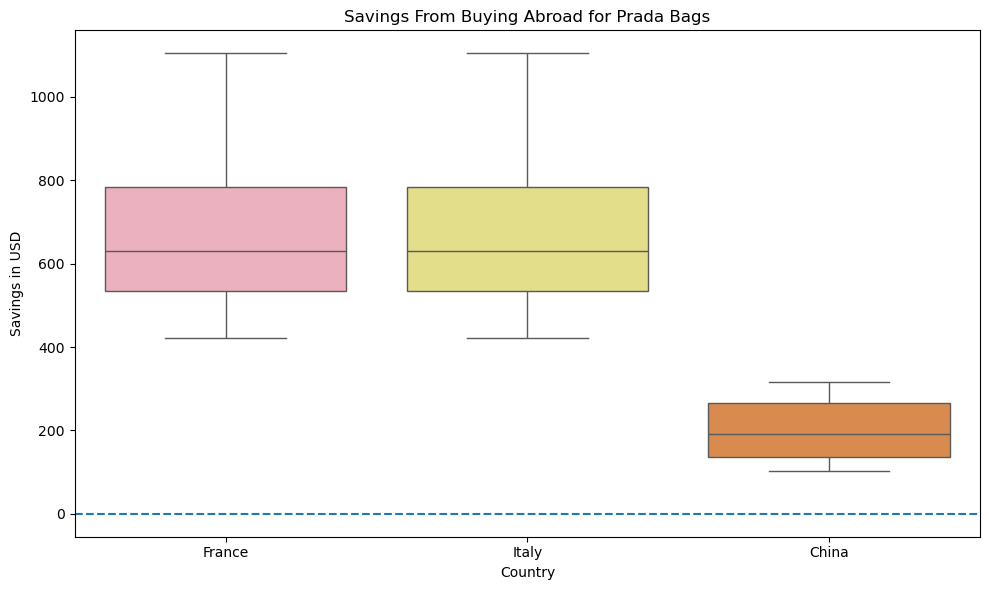

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ----------------------------
# 1. LOAD DATA
# ----------------------------
data = pd.read_csv("prada_10bags_4countries_cleaned.csv", encoding="latin1")
vat = pd.read_csv("vat_rates_by_country.csv")
tariff = pd.read_csv("tariff_data.csv")
fx = pd.read_csv("Currency_Exchange_Rates.csv")

# ----------------------------
# 2. CLEAN + STANDARDIZE
# ----------------------------
vat["country"] = vat["Country"].str.strip()
vat = vat[["country", "Approx_Tax_Refund_Rate"]]

tariff["country"] = tariff["country"].str.strip()
tariff = tariff[["country", "Ad Valorem Rate"]]

fx["country"] = fx["country"].str.strip()
fx = fx[["country", "to_us"]]

# Map country codes
country_map = {
    "US": "US",
    "FR": "France",
    "IT": "Italy",
    "CN": "China"
}
data.columns.tolist()
data["country_full"] = data["country"].map({
    "US": "US",
    "FR": "France",
    "IT": "Italy",
    "CN": "China"
})
data["country_full"] = data["country"].map(country_map)

# ----------------------------
# 3. PIVOT TO WIDE FORMAT
# ----------------------------
wide = (
    data.pivot_table(
        index=["key", "product_name"],
        columns="country_full",
        values="price",
        aggfunc="first"
    )
    .reset_index()
)

# ----------------------------
# 4. LOOKUPS
# ----------------------------
vat_lookup = dict(zip(vat["country"], vat["Approx_Tax_Refund_Rate"]))
fx_lookup = dict(zip(fx["country"], fx["to_us"]))
duty_lookup = dict(zip(tariff["country"], tariff["Ad Valorem Rate"]))

# ----------------------------
# 5. PARAMETERS
# ----------------------------
us_tax = 0.08875

# ----------------------------
# 6. COMPUTE TOTALS
# ----------------------------
wide["US_total"] = wide["US"] * (1 + us_tax)

foreign_countries = ["France", "Italy", "China"]

for c in foreign_countries:
    # Convert to USD
    wide[f"{c}_usd"] = wide[c] * fx_lookup[c]
    
    # VAT refund
    wide[f"{c}_vat_refund"] = wide[f"{c}_usd"] * vat_lookup[c]
    
    # Net price after refund
    wide[f"{c}_net"] = wide[f"{c}_usd"] - wide[f"{c}_vat_refund"]
    
    # Customs duty (applied after refund)
    wide[f"{c}_duty"] = wide[f"{c}_net"] * duty_lookup[c]
    
    # Final landed cost
    wide[f"{c}_total"] = wide[f"{c}_net"] + wide[f"{c}_duty"]

# ----------------------------
# 7. COMPUTE SAVINGS VS US
# ----------------------------
wide["France_savings"] = wide["US_total"] - wide["France_total"]
wide["Italy_savings"] = wide["US_total"] - wide["Italy_total"]
wide["China_savings"] = wide["US_total"] - wide["China_total"]

# ----------------------------
# 8. RESHAPE FOR BOXPLOT
# ----------------------------
savings_df = wide.melt(
    id_vars=["product_name"],
    value_vars=["France_savings", "Italy_savings", "China_savings"],
    var_name="country",
    value_name="savings"
)

savings_df["country"] = savings_df["country"].str.replace("_savings", "")

# ----------------------------
# 9. BOXPLOT
# ----------------------------
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=savings_df,
    x="country",
    y="savings",
    palette={
        "France": colors["France"],
        "Italy": colors["Italy"],
        "China": colors["China"]
    }
)

plt.axhline(0, linestyle="--")  # break-even line

plt.title("Savings From Buying Abroad for Prada Bags")
plt.ylabel("Savings in USD")
plt.xlabel("Country")

plt.tight_layout()
plt.savefig("prada_boxplot.png")
plt.show()

C:\Users\kayla\AppData\Local\Temp\ipykernel_40056\2843391640.py:113: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


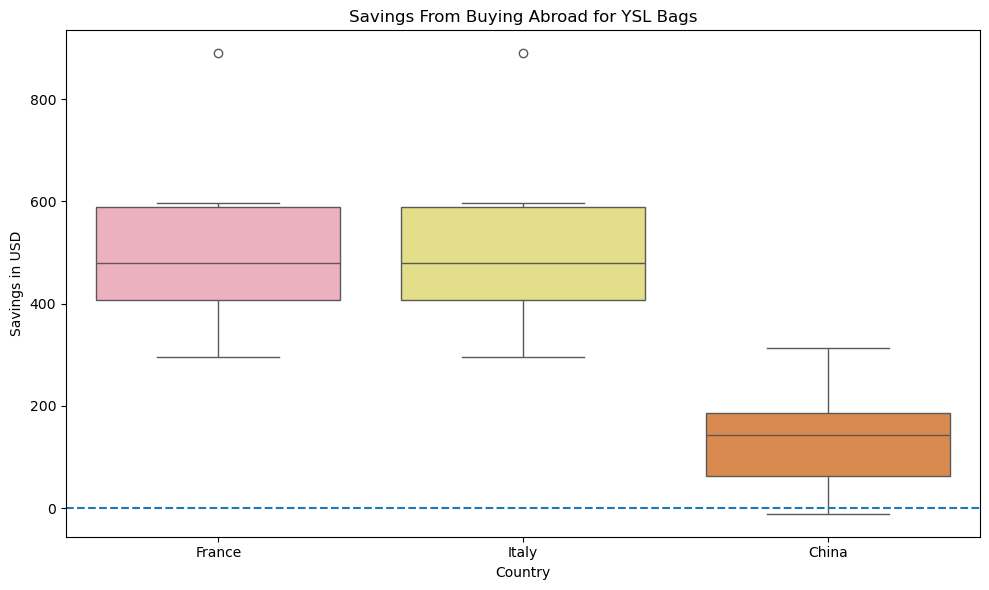

In [55]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ----------------------------
# 1. LOAD DATA
# ----------------------------
data = pd.read_csv("ysl_10bags_4countries_cleaned.csv", encoding="latin1")
vat = pd.read_csv("vat_rates_by_country.csv")
tariff = pd.read_csv("tariff_data.csv")
fx = pd.read_csv("Currency_Exchange_Rates.csv")

# ----------------------------
# 2. CLEAN + STANDARDIZE
# ----------------------------
vat["country"] = vat["Country"].str.strip()
vat = vat[["country", "Approx_Tax_Refund_Rate"]]

tariff["country"] = tariff["country"].str.strip()
tariff = tariff[["country", "Ad Valorem Rate"]]

fx["country"] = fx["country"].str.strip()
fx = fx[["country", "to_us"]]

# Map country codes
country_map = {
    "US": "US",
    "FR": "France",
    "IT": "Italy",
    "CN": "China"
}
data.columns.tolist()
data["country_full"] = data["country"].map({
    "US": "US",
    "FR": "France",
    "IT": "Italy",
    "CN": "China"
})
data["country_full"] = data["country"].map(country_map)

# ----------------------------
# 3. PIVOT TO WIDE FORMAT
# ----------------------------
wide = (
    data.pivot_table(
        index=["sku", "product_name"],
        columns="country_full",
        values="price",
        aggfunc="first"
    )
    .reset_index()
)

# ----------------------------
# 4. LOOKUPS
# ----------------------------
vat_lookup = dict(zip(vat["country"], vat["Approx_Tax_Refund_Rate"]))
fx_lookup = dict(zip(fx["country"], fx["to_us"]))
duty_lookup = dict(zip(tariff["country"], tariff["Ad Valorem Rate"]))

# ----------------------------
# 5. PARAMETERS
# ----------------------------
us_tax = 0.08875

# ----------------------------
# 6. COMPUTE TOTALS
# ----------------------------
wide["US_total"] = wide["US"] * (1 + us_tax)

foreign_countries = ["France", "Italy", "China"]

for c in foreign_countries:
    # Convert to USD
    wide[f"{c}_usd"] = wide[c] * fx_lookup[c]
    
    # VAT refund
    wide[f"{c}_vat_refund"] = wide[f"{c}_usd"] * vat_lookup[c]
    
    # Net price after refund
    wide[f"{c}_net"] = wide[f"{c}_usd"] - wide[f"{c}_vat_refund"]
    
    # Customs duty (applied after refund)
    wide[f"{c}_duty"] = wide[f"{c}_net"] * duty_lookup[c]
    
    # Final landed cost
    wide[f"{c}_total"] = wide[f"{c}_net"] + wide[f"{c}_duty"]

# ----------------------------
# 7. COMPUTE SAVINGS VS US
# ----------------------------
wide["France_savings"] = wide["US_total"] - wide["France_total"]
wide["Italy_savings"] = wide["US_total"] - wide["Italy_total"]
wide["China_savings"] = wide["US_total"] - wide["China_total"]

# ----------------------------
# 8. RESHAPE FOR BOXPLOT
# ----------------------------
savings_df = wide.melt(
    id_vars=["product_name"],
    value_vars=["France_savings", "Italy_savings", "China_savings"],
    var_name="country",
    value_name="savings"
)

savings_df["country"] = savings_df["country"].str.replace("_savings", "")

# ----------------------------
# 9. BOXPLOT
# ----------------------------
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=savings_df,
    x="country",
    y="savings",
    palette={
        "France": colors["France"],
        "Italy": colors["Italy"],
        "China": colors["China"]
    }
)

plt.axhline(0, linestyle="--")  # break-even line

plt.title("Savings From Buying Abroad for YSL Bags")
plt.ylabel("Savings in USD")
plt.xlabel("Country")

plt.tight_layout()
plt.savefig("ysl_boxplot.png")
plt.show()

C:\Users\kayla\AppData\Local\Temp\ipykernel_40940\1457591515.py:113: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


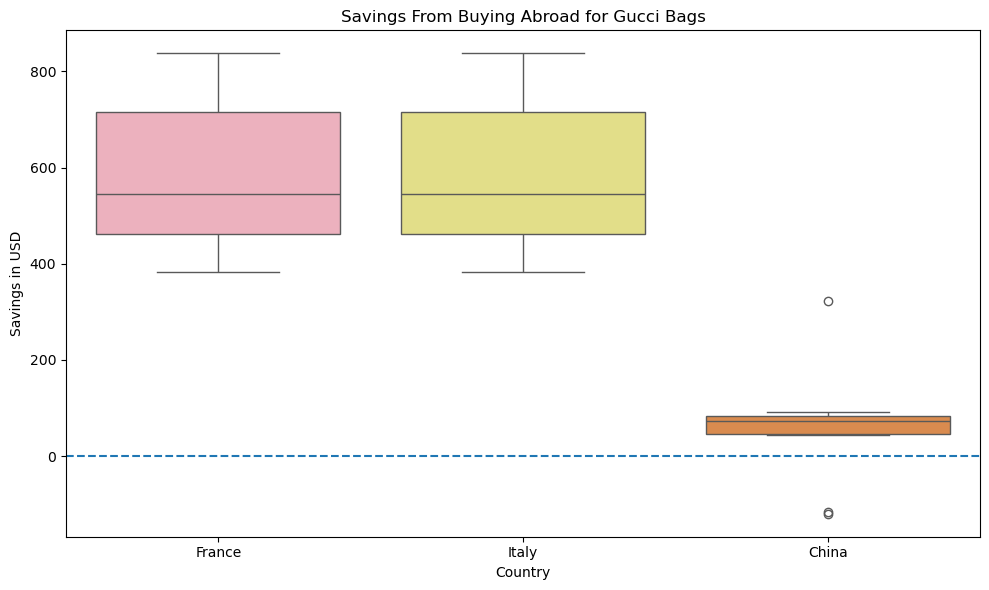

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ----------------------------
# 1. LOAD DATA
# ----------------------------
data = pd.read_csv("gucci_10bags_4countries_cleaned.csv", encoding="latin1")
vat = pd.read_csv("vat_rates_by_country.csv")
tariff = pd.read_csv("tariff_data.csv")
fx = pd.read_csv("Currency_Exchange_Rates.csv")

# ----------------------------
# 2. CLEAN + STANDARDIZE
# ----------------------------
vat["country"] = vat["Country"].str.strip()
vat = vat[["country", "Approx_Tax_Refund_Rate"]]

tariff["country"] = tariff["country"].str.strip()
tariff = tariff[["country", "Ad Valorem Rate"]]

fx["country"] = fx["country"].str.strip()
fx = fx[["country", "to_us"]]

# Map country codes
country_map = {
    "US": "US",
    "FR": "France",
    "IT": "Italy",
    "CN": "China"
}
data.columns.tolist()
data["country_full"] = data["country"].map({
    "US": "US",
    "FR": "France",
    "IT": "Italy",
    "CN": "China"
})
data["country_full"] = data["country"].map(country_map)

# ----------------------------
# 3. PIVOT TO WIDE FORMAT
# ----------------------------
wide = (
    data.pivot_table(
        index=["key", "product_name"],
        columns="country_full",
        values="price",
        aggfunc="first"
    )
    .reset_index()
)

# ----------------------------
# 4. LOOKUPS
# ----------------------------
vat_lookup = dict(zip(vat["country"], vat["Approx_Tax_Refund_Rate"]))
fx_lookup = dict(zip(fx["country"], fx["to_us"]))
duty_lookup = dict(zip(tariff["country"], tariff["Ad Valorem Rate"]))

# ----------------------------
# 5. PARAMETERS
# ----------------------------
us_tax = 0.08875

# ----------------------------
# 6. COMPUTE TOTALS
# ----------------------------
wide["US_total"] = wide["US"] * (1 + us_tax)

foreign_countries = ["France", "Italy", "China"]

for c in foreign_countries:
    # Convert to USD
    wide[f"{c}_usd"] = wide[c] * fx_lookup[c]
    
    # VAT refund
    wide[f"{c}_vat_refund"] = wide[f"{c}_usd"] * vat_lookup[c]
    
    # Net price after refund
    wide[f"{c}_net"] = wide[f"{c}_usd"] - wide[f"{c}_vat_refund"]
    
    # Customs duty (applied after refund)
    wide[f"{c}_duty"] = wide[f"{c}_net"] * duty_lookup[c]
    
    # Final landed cost
    wide[f"{c}_total"] = wide[f"{c}_net"] + wide[f"{c}_duty"]

# ----------------------------
# 7. COMPUTE SAVINGS VS US
# ----------------------------
wide["France_savings"] = wide["US_total"] - wide["France_total"]
wide["Italy_savings"] = wide["US_total"] - wide["Italy_total"]
wide["China_savings"] = wide["US_total"] - wide["China_total"]

# ----------------------------
# 8. RESHAPE FOR BOXPLOT
# ----------------------------
savings_df = wide.melt(
    id_vars=["product_name"],
    value_vars=["France_savings", "Italy_savings", "China_savings"],
    var_name="country",
    value_name="savings"
)

savings_df["country"] = savings_df["country"].str.replace("_savings", "")

# ----------------------------
# 9. BOXPLOT
# ----------------------------
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=savings_df,
    x="country",
    y="savings",
    palette={
        "France": colors["France"],
        "Italy": colors["Italy"],
        "China": colors["China"]
    }
)

plt.axhline(0, linestyle="--")  # break-even line

plt.title("Savings From Buying Abroad for Gucci Bags")
plt.ylabel("Savings in USD")
plt.xlabel("Country")

plt.tight_layout()
plt.savefig("gucci_boxplot.png")
plt.show()

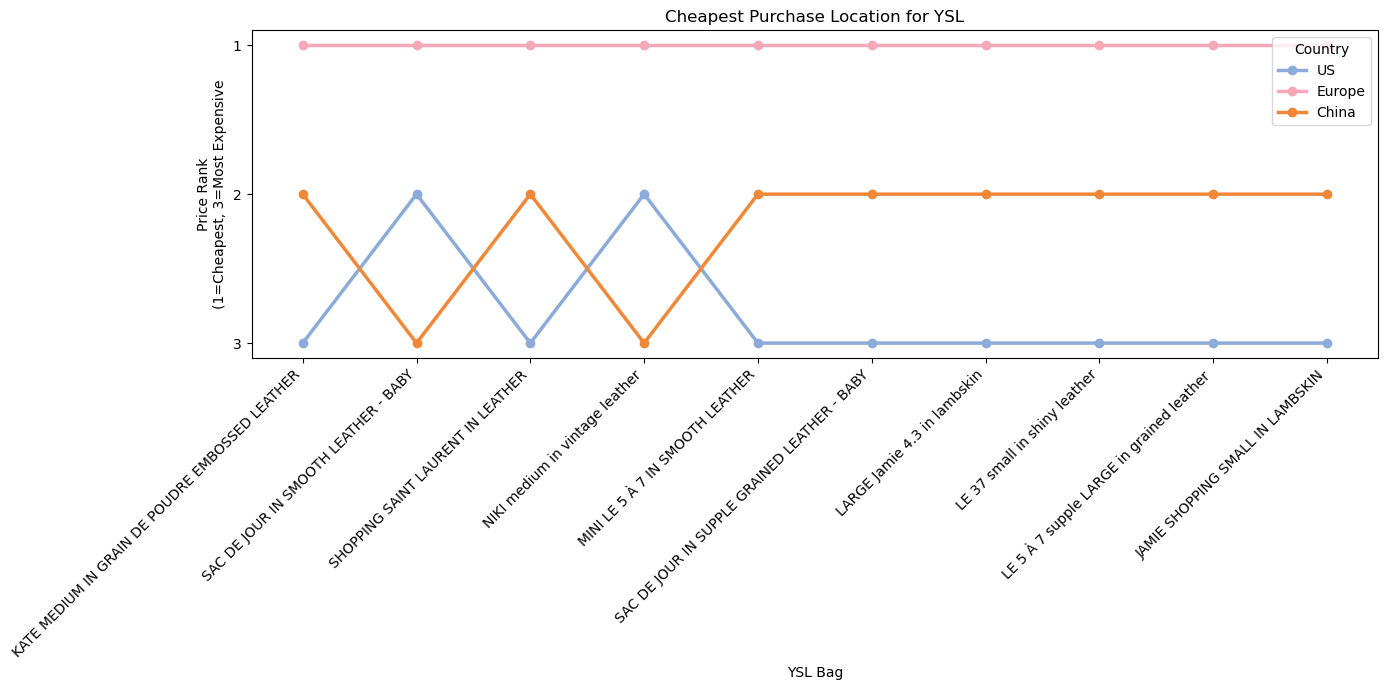

In [79]:
import pandas as pd
import matplotlib.pyplot as plt

# ----------------------------
# 1. LOAD DATA
# ----------------------------
data = pd.read_csv("ysl_10bags_4countries_cleaned.csv")
vat = pd.read_csv("vat_rates_by_country.csv")
tariff = pd.read_csv("tariff_data.csv")
fx = pd.read_csv("Currency_Exchange_Rates.csv")

# ----------------------------
# 2. CLEAN + STANDARDIZE
# ----------------------------
vat["country"] = vat["Country"].str.strip()
vat = vat[["country", "Approx_Tax_Refund_Rate"]]

tariff["country"] = tariff["country"].str.strip()
tariff = tariff[["country", "Ad Valorem Rate"]]

fx["country"] = fx["country"].str.strip()
fx = fx[["country", "to_us"]]

data["country"] = data["country"].str.strip().str.upper()

country_map = {
    "US": "US",
    "FR": "France",
    "IT": "Italy",
    "CN": "China"
}
data["country_full"] = data["country"].map(country_map)

# ----------------------------
# 3. PIVOT TO WIDE FORMAT
# ----------------------------
wide = (
    ysl.pivot_table(
        index=["sku", "product_name"],
        columns="country_full",
        values="price",
        aggfunc="first"
    )
    .reset_index()
)

# ----------------------------
# 4. LOOKUPS
# ----------------------------
vat_lookup = dict(zip(vat["country"], vat["Approx_Tax_Refund_Rate"]))
fx_lookup = dict(zip(fx["country"], fx["to_us"]))
duty_lookup = dict(zip(tariff["country"], tariff["Ad Valorem Rate"]))

# ----------------------------
# 5. PARAMETERS
# ----------------------------
us_tax = 0.08875 

# ----------------------------
# 6. COMPUTE TOTAL LANDED COSTS
# ----------------------------
wide["US_total"] = wide["US"] * (1 + us_tax)

for c in ["France", "Italy", "China"]:
    wide[f"{c}_usd"] = wide[c] * fx_lookup[c]
    wide[f"{c}_vat_refund"] = wide[f"{c}_usd"] * vat_lookup[c]
    wide[f"{c}_net"] = wide[f"{c}_usd"] - wide[f"{c}_vat_refund"]
    wide[f"{c}_duty"] = wide[f"{c}_net"] * duty_lookup[c]
    wide[f"{c}_total"] = wide[f"{c}_net"] + wide[f"{c}_duty"]

# ----------------------------
# 7. COMBINE FRANCE + ITALY INTO EUROPE
# ----------------------------
# Since you said they are always the same, we can just use France_total
wide["Europe_total"] = wide["France_total"]

# ----------------------------
# 8. CREATE RANKING TABLE
# ----------------------------
rank_df = wide[["product_name", "US_total", "Europe_total", "China_total"]].copy()

# rank 1 = cheapest
rank_df["US_rank"] = rank_df[["US_total", "Europe_total", "China_total"]].rank(axis=1, method="min")["US_total"]
rank_df["Europe_rank"] = rank_df[["US_total", "Europe_total", "China_total"]].rank(axis=1, method="min")["Europe_total"]
rank_df["China_rank"] = rank_df[["US_total", "Europe_total", "China_total"]].rank(axis=1, method="min")["China_total"]

# ----------------------------
# 9. RESHAPE FOR BUMP CHART
# ----------------------------
bump_df = rank_df.melt(
    id_vars="product_name",
    value_vars=["US_rank", "Europe_rank", "China_rank"],
    var_name="country",
    value_name="rank"
)

bump_df["country"] = bump_df["country"].str.replace("_rank", "")

# Keep bags in original order
bag_order = rank_df["product_name"].tolist()
bump_df["product_name"] = pd.Categorical(
    bump_df["product_name"],
    categories=bag_order,
    ordered=True
)

# ----------------------------
# 10. BUMP CHART
# ----------------------------
colors = {
    "US": "#8CABD9",
    "Europe": "#F6A7B8",
    "China": "#F08838"
}

plt.figure(figsize=(14, 7))

for country in ["US", "Europe", "China"]:
    temp = bump_df[bump_df["country"] == country].sort_values("product_name")
    plt.plot(
        temp["product_name"],
        temp["rank"],
        marker="o",
        linewidth=2.5,
        label=country,
        color=colors[country]
    )

plt.gca().invert_yaxis()  # so 1 (cheapest) appears at the top
plt.yticks([1, 2, 3], ["1", "2", "3"])
plt.xticks(rotation=45, ha="right")
plt.xlabel("YSL Bag")
plt.ylabel("Price Rank\n(1=Cheapest, 3=Most Expensive")
plt.title("Cheapest Purchase Location for YSL")
plt.legend(title="Country", loc="upper right")
plt.tight_layout()
plt.savefig("ysl_bumpchart.png")
plt.show()

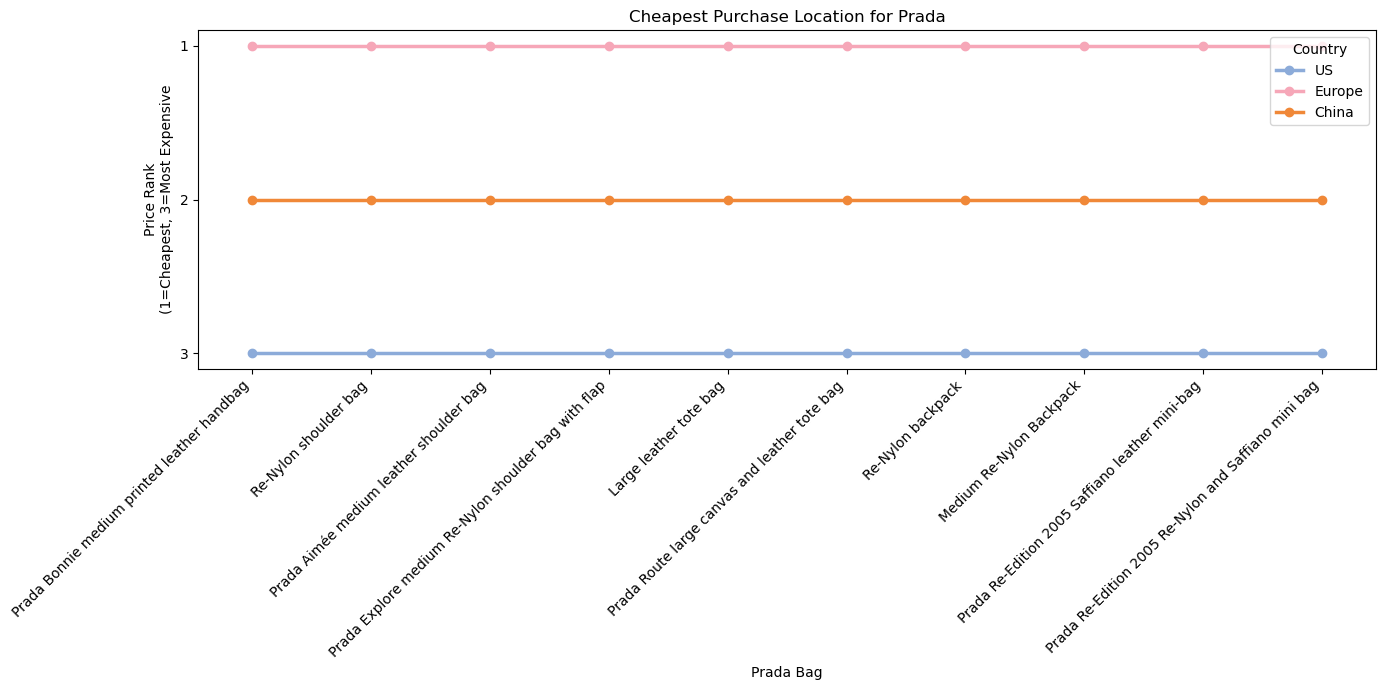

In [69]:
import pandas as pd
import matplotlib.pyplot as plt

# ----------------------------
# 1. LOAD DATA
# ----------------------------
data = pd.read_csv("prada_10bags_4countries_cleaned.csv", encoding="latin1")
vat = pd.read_csv("vat_rates_by_country.csv")
tariff = pd.read_csv("tariff_data.csv")
fx = pd.read_csv("Currency_Exchange_Rates.csv")

# ----------------------------
# 2. CLEAN + STANDARDIZE
# ----------------------------
vat["country"] = vat["Country"].str.strip()
vat = vat[["country", "Approx_Tax_Refund_Rate"]]

tariff["country"] = tariff["country"].str.strip()
tariff = tariff[["country", "Ad Valorem Rate"]]

fx["country"] = fx["country"].str.strip()
fx = fx[["country", "to_us"]]

data["country"] = data["country"].str.strip().str.upper()

country_map = {
    "US": "US",
    "FR": "France",
    "IT": "Italy",
    "CN": "China"
}
data["country_full"] = data["country"].map(country_map)

# ----------------------------
# 3. PIVOT TO WIDE FORMAT
# ----------------------------
wide = (
    data.pivot_table(
        index=["key", "product_name"],
        columns="country_full",
        values="price",
        aggfunc="first"
    )
    .reset_index()
)

# ----------------------------
# 4. LOOKUPS
# ----------------------------
vat_lookup = dict(zip(vat["country"], vat["Approx_Tax_Refund_Rate"]))
fx_lookup = dict(zip(fx["country"], fx["to_us"]))
duty_lookup = dict(zip(tariff["country"], tariff["Ad Valorem Rate"]))

# ----------------------------
# 5. PARAMETERS
# ----------------------------
us_tax = 0.08875 

# ----------------------------
# 6. COMPUTE TOTAL LANDED COSTS
# ----------------------------
wide["US_total"] = wide["US"] * (1 + us_tax)

for c in ["France", "Italy", "China"]:
    wide[f"{c}_usd"] = wide[c] * fx_lookup[c]
    wide[f"{c}_vat_refund"] = wide[f"{c}_usd"] * vat_lookup[c]
    wide[f"{c}_net"] = wide[f"{c}_usd"] - wide[f"{c}_vat_refund"]
    wide[f"{c}_duty"] = wide[f"{c}_net"] * duty_lookup[c]
    wide[f"{c}_total"] = wide[f"{c}_net"] + wide[f"{c}_duty"]

# ----------------------------
# 7. COMBINE FRANCE + ITALY INTO EUROPE
# ----------------------------
# Since you said they are always the same, we can just use France_total
wide["Europe_total"] = wide["France_total"]

# ----------------------------
# 8. CREATE RANKING TABLE
# ----------------------------
rank_df = wide[["product_name", "US_total", "Europe_total", "China_total"]].copy()

# rank 1 = cheapest
rank_df["US_rank"] = rank_df[["US_total", "Europe_total", "China_total"]].rank(axis=1, method="min")["US_total"]
rank_df["Europe_rank"] = rank_df[["US_total", "Europe_total", "China_total"]].rank(axis=1, method="min")["Europe_total"]
rank_df["China_rank"] = rank_df[["US_total", "Europe_total", "China_total"]].rank(axis=1, method="min")["China_total"]

# ----------------------------
# 9. RESHAPE FOR BUMP CHART
# ----------------------------
bump_df = rank_df.melt(
    id_vars="product_name",
    value_vars=["US_rank", "Europe_rank", "China_rank"],
    var_name="country",
    value_name="rank"
)

bump_df["country"] = bump_df["country"].str.replace("_rank", "")

# Keep bags in original order
bag_order = rank_df["product_name"].tolist()
bump_df["product_name"] = pd.Categorical(
    bump_df["product_name"],
    categories=bag_order,
    ordered=True
)

# ----------------------------
# 10. BUMP CHART
# ----------------------------
colors = {
    "US": "#8CABD9",
    "Europe": "#F6A7B8",
    "China": "#F08838"
}

plt.figure(figsize=(14, 7))

for country in ["US", "Europe", "China"]:
    temp = bump_df[bump_df["country"] == country].sort_values("product_name")
    plt.plot(
        temp["product_name"],
        temp["rank"],
        marker="o",
        linewidth=2.5,
        label=country,
        color=colors[country]
    )

plt.gca().invert_yaxis()  # so 1 (cheapest) appears at the top
plt.yticks([1, 2, 3], ["1", "2", "3"])
plt.xticks(rotation=45, ha="right")
plt.xlabel("Prada Bag")
plt.ylabel("Price Rank\n(1=Cheapest, 3=Most Expensive")
plt.title("Cheapest Purchase Location for Prada")
plt.legend(title="Country", loc="upper right")
plt.tight_layout()
plt.savefig("prada_bumpchart.png")
plt.show()

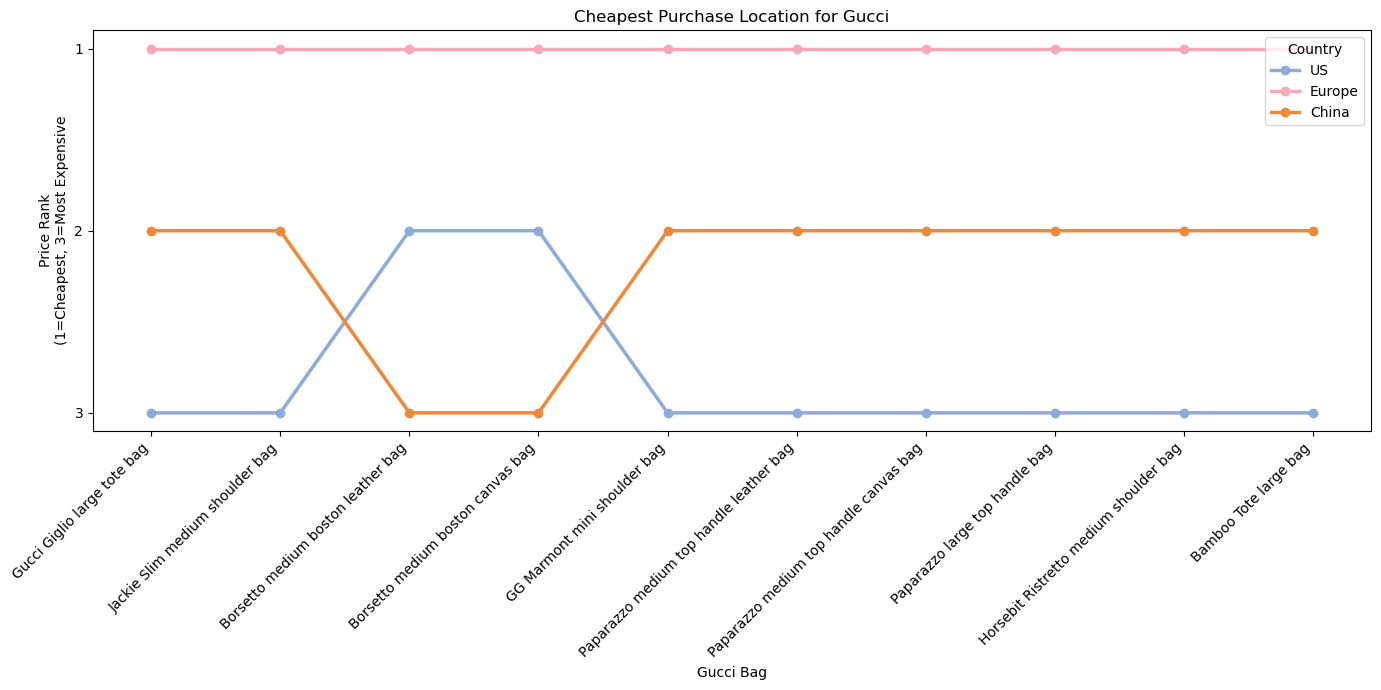

In [11]:
import pandas as pd
import matplotlib.pyplot as plt

# ----------------------------
# 1. LOAD DATA
# ----------------------------
data = pd.read_csv("gucci_10bags_4countries_cleaned.csv", encoding="latin1")
vat = pd.read_csv("vat_rates_by_country.csv")
tariff = pd.read_csv("tariff_data.csv")
fx = pd.read_csv("Currency_Exchange_Rates.csv")

# ----------------------------
# 2. CLEAN + STANDARDIZE
# ----------------------------
vat["country"] = vat["Country"].str.strip()
vat = vat[["country", "Approx_Tax_Refund_Rate"]]

tariff["country"] = tariff["country"].str.strip()
tariff = tariff[["country", "Ad Valorem Rate"]]

fx["country"] = fx["country"].str.strip()
fx = fx[["country", "to_us"]]

data["country"] = data["country"].str.strip().str.upper()

country_map = {
    "US": "US",
    "FR": "France",
    "IT": "Italy",
    "CN": "China"
}
data["country_full"] = data["country"].map(country_map)

# ----------------------------
# 3. PIVOT TO WIDE FORMAT
# ----------------------------
wide = (
    data.pivot_table(
        index=["key", "product_name"],
        columns="country_full",
        values="price",
        aggfunc="first"
    )
    .reset_index()
)

# ----------------------------
# 4. LOOKUPS
# ----------------------------
vat_lookup = dict(zip(vat["country"], vat["Approx_Tax_Refund_Rate"]))
fx_lookup = dict(zip(fx["country"], fx["to_us"]))
duty_lookup = dict(zip(tariff["country"], tariff["Ad Valorem Rate"]))

# ----------------------------
# 5. PARAMETERS
# ----------------------------
us_tax = 0.08875 

# ----------------------------
# 6. COMPUTE TOTAL LANDED COSTS
# ----------------------------
wide["US_total"] = wide["US"] * (1 + us_tax)

for c in ["France", "Italy", "China"]:
    wide[f"{c}_usd"] = wide[c] * fx_lookup[c]
    wide[f"{c}_vat_refund"] = wide[f"{c}_usd"] * vat_lookup[c]
    wide[f"{c}_net"] = wide[f"{c}_usd"] - wide[f"{c}_vat_refund"]
    wide[f"{c}_duty"] = wide[f"{c}_net"] * duty_lookup[c]
    wide[f"{c}_total"] = wide[f"{c}_net"] + wide[f"{c}_duty"]

# ----------------------------
# 7. COMBINE FRANCE + ITALY INTO EUROPE
# ----------------------------
# Since you said they are always the same, we can just use France_total
wide["Europe_total"] = wide["France_total"]

# ----------------------------
# 8. CREATE RANKING TABLE
# ----------------------------
rank_df = wide[["product_name", "US_total", "Europe_total", "China_total"]].copy()

# rank 1 = cheapest
rank_df["US_rank"] = rank_df[["US_total", "Europe_total", "China_total"]].rank(axis=1, method="min")["US_total"]
rank_df["Europe_rank"] = rank_df[["US_total", "Europe_total", "China_total"]].rank(axis=1, method="min")["Europe_total"]
rank_df["China_rank"] = rank_df[["US_total", "Europe_total", "China_total"]].rank(axis=1, method="min")["China_total"]

# ----------------------------
# 9. RESHAPE FOR BUMP CHART
# ----------------------------
bump_df = rank_df.melt(
    id_vars="product_name",
    value_vars=["US_rank", "Europe_rank", "China_rank"],
    var_name="country",
    value_name="rank"
)

bump_df["country"] = bump_df["country"].str.replace("_rank", "")

# Keep bags in original order
bag_order = rank_df["product_name"].tolist()
bump_df["product_name"] = pd.Categorical(
    bump_df["product_name"],
    categories=bag_order,
    ordered=True
)

# ----------------------------
# 10. BUMP CHART
# ----------------------------
colors = {
    "US": "#8CABD9",
    "Europe": "#F6A7B8",
    "China": "#F08838"
}

plt.figure(figsize=(14, 7))

for country in ["US", "Europe", "China"]:
    temp = bump_df[bump_df["country"] == country].sort_values("product_name")
    plt.plot(
        temp["product_name"],
        temp["rank"],
        marker="o",
        linewidth=2.5,
        label=country,
        color=colors[country]
    )

plt.gca().invert_yaxis()  # so 1 (cheapest) appears at the top
plt.yticks([1, 2, 3], ["1", "2", "3"])
plt.xticks(rotation=45, ha="right")
plt.xlabel("Gucci Bag")
plt.ylabel("Price Rank\n(1=Cheapest, 3=Most Expensive")
plt.title("Cheapest Purchase Location for Gucci")
plt.legend(title="Country", loc="upper right")
plt.tight_layout()
plt.savefig("gucci_bumpchart.png")
plt.show()